In [130]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from typing import Literal

In [131]:
SIZE = 1000
SEED = 8
np.random.seed(SEED)
torch.manual_seed(SEED);

### Датасет

In [132]:
X, y = make_classification(SIZE, 2, n_informative=2, n_redundant=0, n_classes=2)

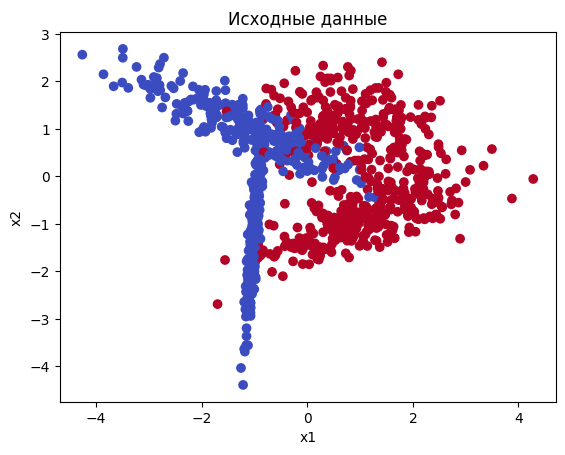

In [133]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title('Исходные данные')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### Нейронная сеть

In [134]:
class MLP(nn.Module):
    def __init__(
        self, 
        input_size: int, 
        hidden_size: int, 
        activation: Literal['relu', 'sigmoid', 'tanh'] = 'relu', 
        output_size: int = 1,
        dropout: float | None = None
    ):
        super().__init__()
        self.ln1 = nn.Linear(input_size, hidden_size)
        self.dout = nn.Dropout(dropout) if dropout is not None else None
        self.actfun = nn.ReLU() if activation == 'relu' else nn.Tanh() if activation == 'tanh' else nn.Sigmoid()
        self.ln2 = nn.Linear(hidden_size, output_size)
        self.outact = nn.Sigmoid()

    def forward(self, x) -> torch.Tensor:
        x = self.ln1(x)
        if self.dout is not None:
            x = self.dout(x)

        x = self.actfun(x)
        x = self.ln2(x)
        return self.outact(x)

    def train_model(self, x, y, epoches: int = 100, opt: Literal['sgd', 'adam', 'rmsprop'] = 'sgd', lr: float = 0.5) -> list[float]:
        optimizer = torch.optim.Adam if opt == 'adam' else torch.optim.RMSprop if opt == 'rmsprop' else torch.optim.SGD
        optimizer = optimizer(self.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss() if self.ln2.out_features > 2 else nn.BCELoss()
        losses = []

        if len(y.shape) != 2:
            y = y.unsqueeze(1)

        for _ in range(epoches):
            optimizer.zero_grad()

            output = self(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        return losses
    

In [135]:
X, y = torch.FloatTensor(X), torch.FloatTensor(y)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [136]:
losses = []
y_pred = []
opts = ['sgd', 'rmsprop', 'adam']
for dout in [None, 0.15]:
    for opt in opts:
        mlp = MLP(2, 8, 'tanh', 1, dout)
        losses.append(mlp.train_model(x_train, y_train, 500, opt, 1.))
        y_pred.append(mlp(x_test)[:, 0] > 0.5)


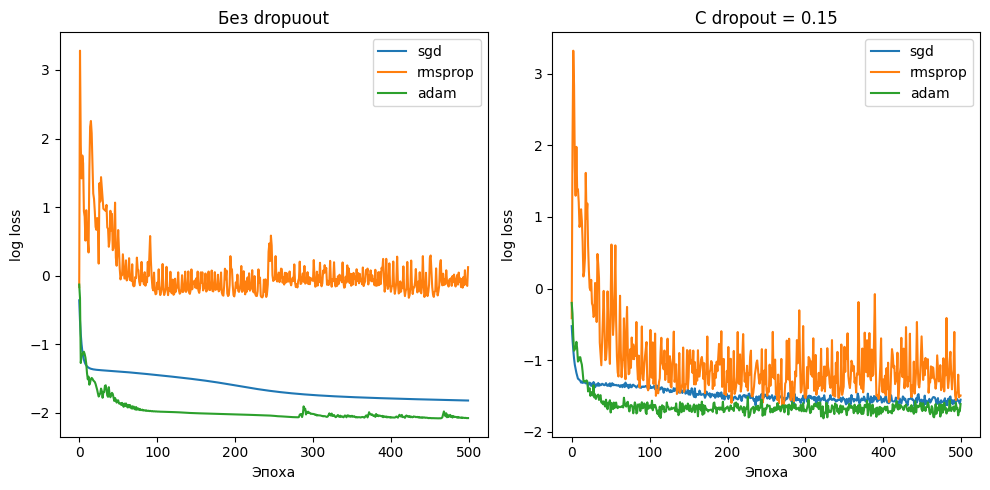

In [137]:
plt.figure(figsize=(10, 5))
for i in range(2):
    plt.subplot(1, 2, i+1)
    for j in range(i*3, (i+1)*3):
        plt.plot(range(500), np.log(losses[j]), label=opts[j % 3])

    plt.xlabel('Эпоха')
    plt.ylabel('log loss')
    plt.title('Без dropuout' if i == 0 else 'С dropout = 0.15')
    plt.legend()

plt.tight_layout();

In [138]:
for i in range(2):
    print('Без dropuout' if i == 0 else 'С dropout = 0.15', '\n')
    for j in range(i*3, (i+1)*3):
        print('\t', opts[j%3], ': ', (y_pred[j] == y_test).sum().item() / len(y_test), sep='')
    
    print()
    

Без dropuout 

	sgd: 0.95
	rmsprop: 0.925
	adam: 0.95

С dropout = 0.15 

	sgd: 0.935
	rmsprop: 0.88
	adam: 0.925



Без dropout график лосс функции при SGD гладкий, при Adam с небольшим шумом, но сходится лучше почти с первых эпох, а RMSProp очень шумный, и лосс остаётся на высоких значениях во время всего обучения.

С dropout графики лосс функции становятся более шумными, RMSProp начинает сходится немного лучше, и в целом разница в сходимости становится меньше между оптимизаторами, но порядок значения лосса при них сохраняется (меньших значений к большим): Adam, SGD, RMSProp.

В данном случае за 500 эпох точность лучше у моделей без dropout.